# e-μ Flavor Control Region (Resolved)

Reproduce the resolved e-μ Flavor CR selection from `Reproduce20_002_copy.cc`.

## Cut flow
1. Noise filter
2. Lepton selection (Tight / Loose)
3. Fat-jet & jet selection + cleaning
4. Jet veto map  ← skipped at NanoAOD level (applied in framework)
5. Exactly **1 tight muon + 1 tight electron**, l1 pT > 60, l2 pT > 53
6. Muon trigger (HLT_Mu50 family)
7. ≥ 2 jets, ΔR(jet–lep) > 0.4, ΔR(lep–lep) > 0.4, ΔR(j–j) > 0.4
8. **Flavor CR**: m(ll) > 400 GeV  AND  m(lljj) > 800 GeV

Lepton IDs used in the C++ code:
- **Tight electron**: `Electron_cutBased ≥ 4` (Tight WP) — matches `Electron_Tight_ID`
- **Loose electron**: `Electron_cutBased ≥ 1` OR `Electron_cutBased_HEEP == True`
- **Tight muon**: `Muon_highPtId == 2` (GlobalHighPt) AND `Muon_tkRelIso < 0.1`
- **Loose muon**: `Muon_looseId == True`

In [1]:
import glob
import os
import numpy as np
import awkward as ak
import uproot
import vector
from tqdm import tqdm

vector.register_awkward()

## Input files
WR → N(e) → eeJJ signal (2023) as a test sample.  
Replace `INPUT_FILES` with any NanoAODv12 sample to study.

In [2]:
# ── 입력 파일 설정 ─────────────────────────────────────────────────────────────
# 아래 경로를 원하는 NanoAOD 샘플로 교체하세요.
BASE_DIR = (
    "/gv0/Users/achihwan/SKNano/Run3NanoAODv12/2023/"
    "WRtoNEltoElElJJ_MWR2000_N100_TuneCP5_13p6TeV_madgraph-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2"
)
INPUT_FILES = sorted(glob.glob(os.path.join(BASE_DIR, "**/*.root"), recursive=True))
print(f"파일 수: {len(INPUT_FILES)}")
for f in INPUT_FILES:
    print(" ", f)

파일 수: 11
  /gv0/Users/achihwan/SKNano/Run3NanoAODv12/2023/WRtoNEltoElElJJ_MWR2000_N100_TuneCP5_13p6TeV_madgraph-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2/120000/219de6d2-7ffb-40c7-8b63-5a8089d8b217.root
  /gv0/Users/achihwan/SKNano/Run3NanoAODv12/2023/WRtoNEltoElElJJ_MWR2000_N100_TuneCP5_13p6TeV_madgraph-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2/120000/2f29533d-ee56-4de8-9421-59810a2c7e43.root
  /gv0/Users/achihwan/SKNano/Run3NanoAODv12/2023/WRtoNEltoElElJJ_MWR2000_N100_TuneCP5_13p6TeV_madgraph-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2/120000/3eec7917-f1b1-494a-9dd9-5e0b3d6af46b.root
  /gv0/Users/achihwan/SKNano/Run3NanoAODv12/2023/WRtoNEltoElElJJ_MWR2000_N100_TuneCP5_13p6TeV_madgraph-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2/120000/415496fa-0e76-4e5d-8e94-61c4f03facbe.root
  /gv0/Users/achihwan/SKNano/Run3NanoAODv12/2023/WRtoNEltoElElJJ_MWR2000_N100_TuneCP5_13p6TeV_madgraph-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2/120000/58330688

## Era-dependent trigger thresholds (2022 / 2022EE / 2023 / 2023BPix)

In [3]:
DATA_ERA = "2023"   # 2022 / 2022EE / 2023 / 2023BPix / 2017

ERA_CONFIG = {
    "2017":      {"mu_trig_pt": 52., "el_trig_pt": 38.,
                  "mu_triggers": ["HLT_Mu50", "HLT_OldMu100", "HLT_TkMu100"],
                  "el_triggers": ["HLT_Ele35_WPTight_Gsf", "HLT_Photon200",
                                   "HLT_Ele115_CaloIdVT_GsfTrkIdT"]},
    "2022":      {"mu_trig_pt": 52., "el_trig_pt": 118.,
                  "mu_triggers": ["HLT_Mu50", "HLT_CascadeMu100", "HLT_HighPtTkMu100"],
                  "el_triggers": ["HLT_Photon200", "HLT_Ele115_CaloIdVT_GsfTrkIdT"]},
    "2022EE":    {"mu_trig_pt": 52., "el_trig_pt": 118.,
                  "mu_triggers": ["HLT_Mu50", "HLT_CascadeMu100", "HLT_HighPtTkMu100"],
                  "el_triggers": ["HLT_Photon200", "HLT_Ele115_CaloIdVT_GsfTrkIdT"]},
    "2023":      {"mu_trig_pt": 52., "el_trig_pt": 118.,
                  "mu_triggers": ["HLT_Mu50", "HLT_CascadeMu100", "HLT_HighPtTkMu100"],
                  "el_triggers": ["HLT_Photon200", "HLT_Ele115_CaloIdVT_GsfTrkIdT"]},
    "2023BPix":  {"mu_trig_pt": 52., "el_trig_pt": 118.,
                  "mu_triggers": ["HLT_Mu50", "HLT_CascadeMu100", "HLT_HighPtTkMu100"],
                  "el_triggers": ["HLT_Photon200", "HLT_Ele115_CaloIdVT_GsfTrkIdT"]},
}

cfg = ERA_CONFIG[DATA_ERA]
MU_TRIG_SAFE_PT  = cfg["mu_trig_pt"]
EL_TRIG_SAFE_PT  = cfg["el_trig_pt"]
MU_TRIGGER_LIST  = cfg["mu_triggers"]
EL_TRIGGER_LIST  = cfg["el_triggers"]
print(f"Era: {DATA_ERA}")
print(f"  Muon trigger safe pT: {MU_TRIG_SAFE_PT}")
print(f"  Electron trigger safe pT: {EL_TRIG_SAFE_PT}")
print(f"  Muon triggers: {MU_TRIGGER_LIST}")

Era: 2023
  Muon trigger safe pT: 52.0
  Electron trigger safe pT: 118.0
  Muon triggers: ['HLT_Mu50', 'HLT_CascadeMu100', 'HLT_HighPtTkMu100']


## Helper functions

In [4]:
def delta_phi(phi1, phi2):
    """Wrapped ΔΦ in [-π, π]."""
    dphi = phi1 - phi2
    dphi = ak.where(dphi >  np.pi, dphi - 2*np.pi, dphi)
    dphi = ak.where(dphi < -np.pi, dphi + 2*np.pi, dphi)
    return dphi


def delta_r(eta1, phi1, eta2, phi2):
    deta = eta1 - eta2
    dphi = delta_phi(phi1, phi2)
    return np.sqrt(deta**2 + dphi**2)


def pass_any_trigger(events, trigger_list):
    """Return a boolean array: True if at least one trigger in the list fired."""
    result = None
    for trig in trigger_list:
        try:
            fired = events[trig].array() != 0
            result = fired if result is None else (result | fired)
        except Exception:
            pass
    if result is None:
        raise ValueError(f"None of {trigger_list} found in file")
    return result


def make_4vec(pt, eta, phi, mass):
    """Build an awkward 4-vector array."""
    return ak.zip(
        {"pt": pt, "eta": eta, "phi": phi, "mass": mass},
        with_name="Momentum4D",
        behavior=vector.backends.awkward.behavior,
    )


def clean_jets_vs_leptons(jet_eta, jet_phi, lep_eta, lep_phi, dr_cut=0.4):
    """Per-jet mask: True if the jet is NOT within dr_cut of any lepton. (ev,j) + (ev,l)"""
    dr = delta_r(
        jet_eta[:, :, np.newaxis], jet_phi[:, :, np.newaxis],
        lep_eta[:, np.newaxis, :], lep_phi[:, np.newaxis, :],
    )
    return ak.all(dr > dr_cut, axis=2)


def inv_mass_2(pt1, eta1, phi1, m1, pt2, eta2, phi2, m2):
    """Invariant mass of two particles (broadcasted)."""
    e1  = pt1  * np.cosh(eta1)
    e2  = pt2  * np.cosh(eta2)
    px1 = pt1  * np.cos(phi1);  py1 = pt1  * np.sin(phi1);  pz1 = pt1  * np.sinh(eta1)
    px2 = pt2  * np.cos(phi2);  py2 = pt2  * np.sin(phi2);  pz2 = pt2  * np.sinh(eta2)
    m2v = (e1+e2)**2 - (px1+px2)**2 - (py1+py2)**2 - (pz1+pz2)**2
    return np.sqrt(ak.where(m2v > 0, m2v, 0.))

## e-μ Flavor CR selection

Run over all input files and accumulate events that pass every cut.

In [5]:
# ── 누적 리스트 ───────────────────────────────────────────────────────────────
out = {
    "mll":             [],
    "mlljj":           [],
    "dilepton_pt":     [],
    "lead_lep_pt":     [],
    "sublead_lep_pt":  [],
    "lead_jet_pt":     [],
    "sublead_jet_pt":  [],
    "n_jets":          [],
    "charge_product":  [],   # >0: SS, <0: OS
}

cutflow = {
    "all":          0,
    "2_tight_lep_pt": 0,
    "is_EM":        0,
    "mu_trig_pt":   0,
    "mu_trigger":   0,
    "2_jets_dR":    0,
    "flav_CR":      0,
}

BRANCHES = [
    # Electrons
    "Electron_pt", "Electron_eta", "Electron_phi", "Electron_mass",
    "Electron_charge", "Electron_cutBased", "Electron_cutBased_HEEP",
    # Muons
    "Muon_pt", "Muon_eta", "Muon_phi", "Muon_mass",
    "Muon_charge", "Muon_highPtId", "Muon_tkRelIso", "Muon_looseId",
    # Jets (AK4)
    "Jet_pt", "Jet_eta", "Jet_phi", "Jet_mass", "Jet_jetId",
]

def safe_idx(arr, idx):
    """Index into a variable-length awkward array at position idx safely.
    Pads with None so events shorter than idx+1 return None instead of raising."""
    return ak.fill_none(ak.pad_none(arr, idx + 1)[:, idx], 0.0)

for fpath in tqdm(INPUT_FILES, desc="Files"):
    try:
        f      = uproot.open(fpath)
        events = f["Events"]
    except Exception as e:
        print(f"Cannot open {fpath}: {e}")
        continue

    available = set(events.keys())
    load_branches = [b for b in BRANCHES if b in available]
    arrays = events.arrays(load_branches)

    n_ev = len(arrays["Electron_pt"])
    cutflow["all"] += n_ev

    # ── Tight electrons ───────────────────────────────────────────────────────
    el_tight_mask = (
        (arrays["Electron_pt"]  > 10.) &
        (np.abs(arrays["Electron_eta"]) < 2.5) &
        (arrays["Electron_cutBased"] >= 4)
    )
    el_tight_pt   = arrays["Electron_pt"]  [el_tight_mask]
    el_tight_eta  = arrays["Electron_eta"] [el_tight_mask]
    el_tight_phi  = arrays["Electron_phi"] [el_tight_mask]
    el_tight_mass = arrays["Electron_mass"][el_tight_mask]
    el_tight_q    = arrays["Electron_charge"][el_tight_mask]

    # ── Tight muons ───────────────────────────────────────────────────────────
    mu_tight_mask = (
        (arrays["Muon_pt"]  > 10.) &
        (np.abs(arrays["Muon_eta"]) < 2.4) &
        (arrays["Muon_highPtId"] == 2) &
        (arrays["Muon_tkRelIso"] < 0.1)
    )
    mu_tight_pt   = arrays["Muon_pt"]  [mu_tight_mask]
    mu_tight_eta  = arrays["Muon_eta"] [mu_tight_mask]
    mu_tight_phi  = arrays["Muon_phi"] [mu_tight_mask]
    mu_tight_mass = arrays["Muon_mass"][mu_tight_mask]
    mu_tight_q    = arrays["Muon_charge"][mu_tight_mask]

    # ── Loose leptons (for jet cleaning) ─────────────────────────────────────
    el_loose_mask = (
        (arrays["Electron_pt"]  > 10.) &
        (np.abs(arrays["Electron_eta"]) < 2.5) &
        ((arrays["Electron_cutBased"] >= 1) | (arrays["Electron_cutBased_HEEP"] == True))
    )
    mu_loose_mask = (
        (arrays["Muon_pt"]  > 10.) &
        (np.abs(arrays["Muon_eta"]) < 2.4) &
        (arrays["Muon_looseId"] == True)
    )
    loose_lep_eta = ak.concatenate(
        [arrays["Electron_eta"][el_loose_mask], arrays["Muon_eta"][mu_loose_mask]], axis=1
    )
    loose_lep_phi = ak.concatenate(
        [arrays["Electron_phi"][el_loose_mask], arrays["Muon_phi"][mu_loose_mask]], axis=1
    )

    # ── Jets: base selection + cleaning ──────────────────────────────────────
    jet_base_mask = (
        (arrays["Jet_pt"]  > 30.) &
        (np.abs(arrays["Jet_eta"]) < 2.4) &
        (arrays["Jet_jetId"] >= 2)
    )
    jet_pt_all   = arrays["Jet_pt"] [jet_base_mask]
    jet_eta_all  = arrays["Jet_eta"][jet_base_mask]
    jet_phi_all  = arrays["Jet_phi"][jet_base_mask]
    jet_mass_all = arrays["Jet_mass"][jet_base_mask]

    if ak.sum(ak.num(loose_lep_eta)) > 0:
        jet_clean_mask = clean_jets_vs_leptons(
            jet_eta_all, jet_phi_all, loose_lep_eta, loose_lep_phi
        )
    else:
        jet_clean_mask = ak.ones_like(jet_pt_all, dtype=bool)

    jet_pt   = jet_pt_all  [jet_clean_mask]
    jet_eta  = jet_eta_all [jet_clean_mask]
    jet_phi  = jet_phi_all [jet_clean_mask]
    jet_mass = jet_mass_all[jet_clean_mask]

    # ── Muon trigger ─────────────────────────────────────────────────────────
    trig_mu_pass = pass_any_trigger(events, MU_TRIGGER_LIST)

    # ── CUT 1: exactly 1 tight e + 1 tight μ, lead pT>60, sublead pT>53 ─────
    n_tight_el = ak.num(el_tight_pt)
    n_tight_mu = ak.num(mu_tight_pt)
    is_EM = (n_tight_el == 1) & (n_tight_mu == 1)

    mu_lead_pt = ak.firsts(mu_tight_pt)   # (ev,) — the single tight muon
    el_lead_pt = ak.firsts(el_tight_pt)   # (ev,) — the single tight electron

    lead_pt    = ak.where(mu_lead_pt >= el_lead_pt, mu_lead_pt, el_lead_pt)
    sublead_pt = ak.where(mu_lead_pt >= el_lead_pt, el_lead_pt, mu_lead_pt)
    pt_cuts = (lead_pt > 60.) & (sublead_pt > 53.)

    sel_2lep = is_EM & pt_cuts
    cutflow["2_tight_lep_pt"] += int(ak.sum(sel_2lep))
    cutflow["is_EM"]          += int(ak.sum(sel_2lep))

    # ── CUT 2: muon trigger safe pT & HLT ────────────────────────────────────
    sel_mu_trig_pt = sel_2lep & (mu_lead_pt > MU_TRIG_SAFE_PT)
    cutflow["mu_trig_pt"] += int(ak.sum(sel_mu_trig_pt))

    sel_trig = sel_mu_trig_pt & trig_mu_pass
    cutflow["mu_trigger"] += int(ak.sum(sel_trig))

    # ── CUT 3: ≥2 jets with dR cuts ──────────────────────────────────────────
    ev_mask = sel_trig

    el_pt_m    = el_tight_pt  [ev_mask]
    el_eta_m   = el_tight_eta [ev_mask]
    el_phi_m   = el_tight_phi [ev_mask]
    el_mass_m  = el_tight_mass[ev_mask]
    el_q_m     = el_tight_q   [ev_mask]

    mu_pt_m    = mu_tight_pt  [ev_mask]
    mu_eta_m   = mu_tight_eta [ev_mask]
    mu_phi_m   = mu_tight_phi [ev_mask]
    mu_mass_m  = mu_tight_mass[ev_mask]
    mu_q_m     = mu_tight_q   [ev_mask]

    jet_pt_m   = jet_pt  [ev_mask]
    jet_eta_m  = jet_eta [ev_mask]
    jet_phi_m  = jet_phi [ev_mask]
    jet_mass_m = jet_mass[ev_mask]

    # Clean jets vs both tight leptons
    lep_eta_2 = ak.concatenate(
        [ak.firsts(el_eta_m)[:, np.newaxis], ak.firsts(mu_eta_m)[:, np.newaxis]], axis=1
    )
    lep_phi_2 = ak.concatenate(
        [ak.firsts(el_phi_m)[:, np.newaxis], ak.firsts(mu_phi_m)[:, np.newaxis]], axis=1
    )
    jet_ok_mask = clean_jets_vs_leptons(jet_eta_m, jet_phi_m, lep_eta_2, lep_phi_2)

    jet_pt_sel   = jet_pt_m  [jet_ok_mask]
    jet_eta_sel  = jet_eta_m [jet_ok_mask]
    jet_phi_sel  = jet_phi_m [jet_ok_mask]
    jet_mass_sel = jet_mass_m[jet_ok_mask]

    # lepton–lepton dR
    dr_ll = delta_r(
        ak.firsts(el_eta_m), ak.firsts(el_phi_m),
        ak.firsts(mu_eta_m), ak.firsts(mu_phi_m)
    )

    has_2j = ak.num(jet_pt_sel) >= 2

    # Pad to 2 before indexing — avoids IndexError on short events
    jet_eta_p2 = ak.pad_none(jet_eta_sel, 2)
    jet_phi_p2 = ak.pad_none(jet_phi_sel, 2)

    dr_j1j2 = ak.where(
        has_2j,
        delta_r(
            ak.fill_none(jet_eta_p2[:, 0], 0.0), ak.fill_none(jet_phi_p2[:, 0], 0.0),
            ak.fill_none(jet_eta_p2[:, 1], 0.0), ak.fill_none(jet_phi_p2[:, 1], 0.0),
        ),
        0.0,
    )

    sel_jets = has_2j & (dr_ll > 0.4) & (dr_j1j2 > 0.4)
    cutflow["2_jets_dR"] += int(ak.sum(sel_jets))

    # ── CUT 4 (Flavor CR): m(ll)>400, m(lljj)>800 ────────────────────────────
    ev2_mask = sel_jets

    el_pt_f    = el_pt_m  [ev2_mask]
    el_eta_f   = el_eta_m [ev2_mask]
    el_phi_f   = el_phi_m [ev2_mask]
    el_mass_f  = el_mass_m[ev2_mask]
    el_q_f     = el_q_m   [ev2_mask]

    mu_pt_f    = mu_pt_m  [ev2_mask]
    mu_eta_f   = mu_eta_m [ev2_mask]
    mu_phi_f   = mu_phi_m [ev2_mask]
    mu_mass_f  = mu_mass_m[ev2_mask]
    mu_q_f     = mu_q_m   [ev2_mask]

    jet_pt_f   = jet_pt_sel  [ev2_mask]
    jet_eta_f  = jet_eta_sel [ev2_mask]
    jet_phi_f  = jet_phi_sel [ev2_mask]
    jet_mass_f = jet_mass_sel[ev2_mask]

    # Pad jets to 2 before indexed access
    jet_pt_p2   = ak.pad_none(jet_pt_f,   2)
    jet_eta_p2f = ak.pad_none(jet_eta_f,  2)
    jet_phi_p2f = ak.pad_none(jet_phi_f,  2)
    jet_mass_p2 = ak.pad_none(jet_mass_f, 2)

    el_vec = make_4vec(
        ak.fill_none(ak.firsts(el_pt_f),   0.0),
        ak.fill_none(ak.firsts(el_eta_f),  0.0),
        ak.fill_none(ak.firsts(el_phi_f),  0.0),
        ak.fill_none(ak.firsts(el_mass_f), 0.0),
    )
    mu_vec = make_4vec(
        ak.fill_none(ak.firsts(mu_pt_f),   0.0),
        ak.fill_none(ak.firsts(mu_eta_f),  0.0),
        ak.fill_none(ak.firsts(mu_phi_f),  0.0),
        ak.fill_none(ak.firsts(mu_mass_f), 0.0),
    )
    j1_vec = make_4vec(
        ak.fill_none(jet_pt_p2  [:, 0], 0.0),
        ak.fill_none(jet_eta_p2f[:, 0], 0.0),
        ak.fill_none(jet_phi_p2f[:, 0], 0.0),
        ak.fill_none(jet_mass_p2[:, 0], 0.0),
    )
    j2_vec = make_4vec(
        ak.fill_none(jet_pt_p2  [:, 1], 0.0),
        ak.fill_none(jet_eta_p2f[:, 1], 0.0),
        ak.fill_none(jet_phi_p2f[:, 1], 0.0),
        ak.fill_none(jet_mass_p2[:, 1], 0.0),
    )

    ll_vec   = el_vec + mu_vec
    lljj_vec = ll_vec + j1_vec + j2_vec

    mll   = ll_vec.mass
    mlljj = lljj_vec.mass

    sel_flav_CR = (mll > 400.) & (mlljj > 800.)
    cutflow["flav_CR"] += int(ak.sum(sel_flav_CR))

    # ── Store results ─────────────────────────────────────────────────────────
    mu_pt_fCR  = ak.fill_none(ak.firsts(mu_pt_f), 0.0)[sel_flav_CR]
    el_pt_fCR  = ak.fill_none(ak.firsts(el_pt_f), 0.0)[sel_flav_CR]

    out["mll"]           .append(ak.to_numpy(mll  [sel_flav_CR]))
    out["mlljj"]         .append(ak.to_numpy(mlljj[sel_flav_CR]))
    out["dilepton_pt"]   .append(ak.to_numpy(ll_vec.pt[sel_flav_CR]))
    out["lead_lep_pt"]   .append(ak.to_numpy(ak.where(mu_pt_fCR >= el_pt_fCR, mu_pt_fCR, el_pt_fCR)))
    out["sublead_lep_pt"].append(ak.to_numpy(ak.where(mu_pt_fCR >= el_pt_fCR, el_pt_fCR, mu_pt_fCR)))
    out["lead_jet_pt"]   .append(ak.to_numpy(ak.fill_none(jet_pt_p2[:, 0], 0.0)[sel_flav_CR]))
    out["sublead_jet_pt"].append(ak.to_numpy(ak.fill_none(jet_pt_p2[:, 1], 0.0)[sel_flav_CR]))
    out["n_jets"]        .append(ak.to_numpy(ak.num(jet_pt_f)[sel_flav_CR]))
    out["charge_product"].append(ak.to_numpy(
        (ak.fill_none(ak.firsts(mu_q_f), 0) * ak.fill_none(ak.firsts(el_q_f), 0))[sel_flav_CR]
    ))

# ── Concatenate ───────────────────────────────────────────────────────────────
for k in out:
    out[k] = np.concatenate(out[k]) if out[k] else np.array([])

print("\n=== Cutflow ===")
for step, n in cutflow.items():
    print(f"  {step:25s}: {n}")

print(f"\nFlavor CR events: {len(out['mll'])}")

Files:   0%|          | 0/11 [00:00<?, ?it/s]

Files: 100%|██████████| 11/11 [00:14<00:00,  1.30s/it]


=== Cutflow ===
  all                      : 70000
  2_tight_lep_pt           : 7
  is_EM                    : 7
  mu_trig_pt               : 7
  mu_trigger               : 7
  2_jets_dR                : 4
  flav_CR                  : 3

Flavor CR events: 3


## Results

In [6]:
mll   = out["mll"]
mlljj = out["mlljj"]
q     = out["charge_product"]

n_total = len(mll)
n_OS    = int(np.sum(q < 0))
n_SS    = int(np.sum(q > 0))

print(f"Flavor CR (e-mu, resolved): {n_total} events")
print(f"  OS (opposite sign) : {n_OS}")
print(f"  SS (same sign)     : {n_SS}")
if n_total > 0:
    print(f"  mll   : min={mll.min():.1f}  max={mll.max():.1f}  mean={mll.mean():.1f} GeV")
    print(f"  mlljj : min={mlljj.min():.1f}  max={mlljj.max():.1f}  mean={mlljj.mean():.1f} GeV")

Flavor CR (e-mu, resolved): 3 events
  OS (opposite sign) : 2
  SS (same sign)     : 1
  mll   : min=677.0  max=936.1  mean=789.8 GeV
  mlljj : min=1848.1  max=2308.7  mean=2035.0 GeV


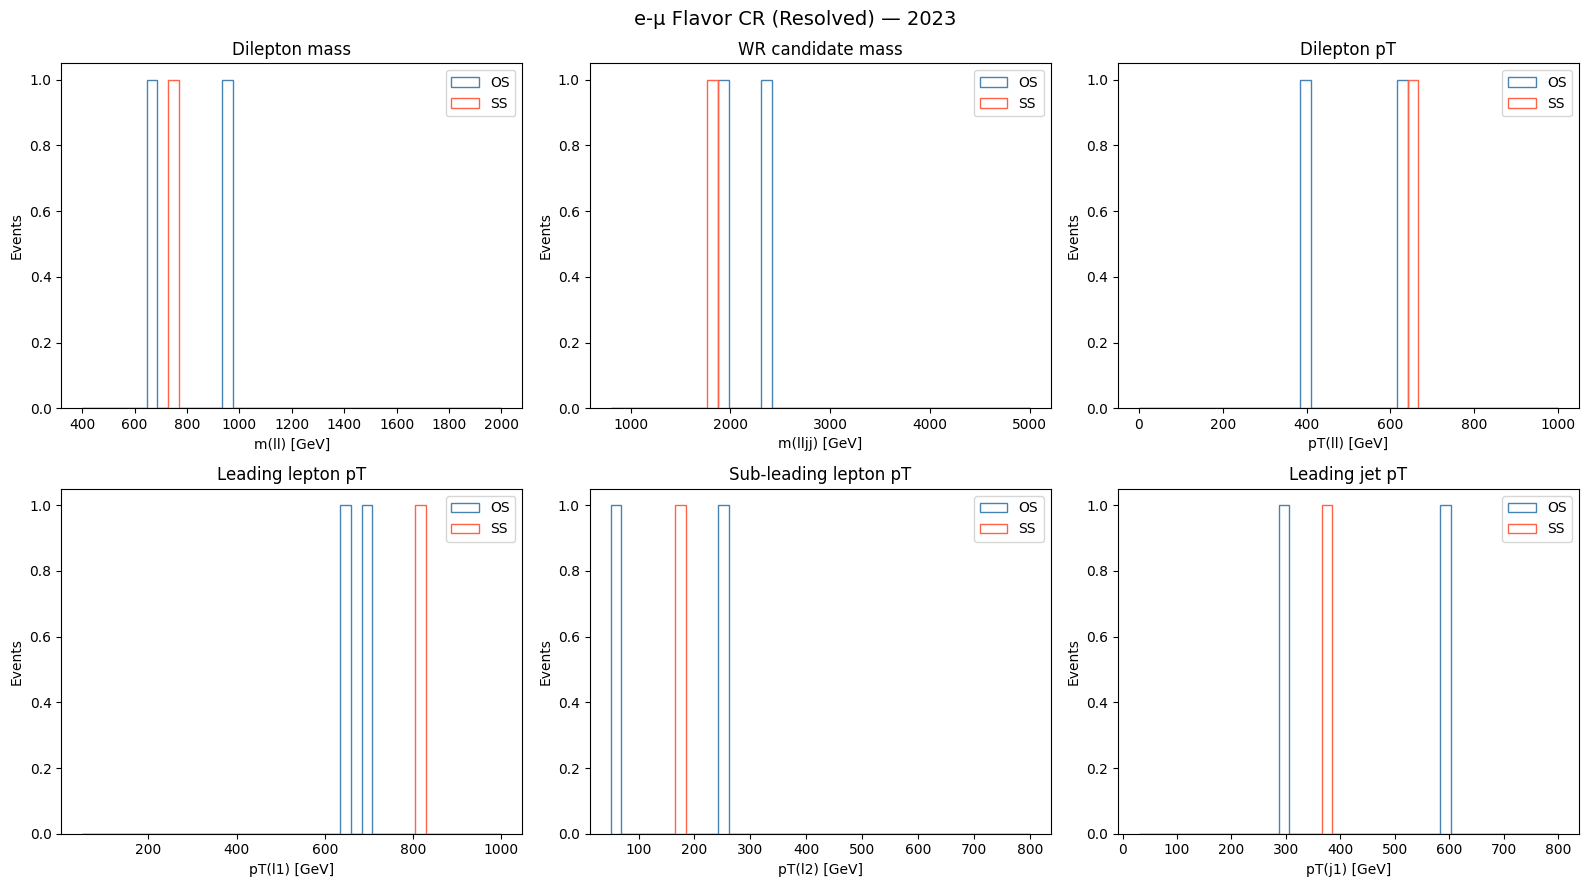

Saved: emu_flavor_CR.png


In [7]:
import matplotlib.pyplot as plt

mll   = out["mll"]
mlljj = out["mlljj"]
q     = out["charge_product"]

if len(mll) == 0:
    print("No events in Flavor CR — nothing to plot.")
else:
    OS = q < 0
    SS = q > 0

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle(f"e-μ Flavor CR (Resolved) — {DATA_ERA}", fontsize=14)

    def hist(ax, data, bins, xlabel, title):
        ax.hist(data[OS], bins=bins, histtype="step", label="OS", color="steelblue")
        ax.hist(data[SS], bins=bins, histtype="step", label="SS", color="tomato")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Events")
        ax.set_title(title)
        ax.legend()

    hist(axes[0, 0], mll,                    np.linspace(400, 2000, 40), "m(ll) [GeV]",        "Dilepton mass")
    hist(axes[0, 1], mlljj,                  np.linspace(800, 5000, 40), "m(lljj) [GeV]",      "WR candidate mass")
    hist(axes[0, 2], out["dilepton_pt"],     np.linspace(0,  1000, 40), "pT(ll) [GeV]",       "Dilepton pT")
    hist(axes[1, 0], out["lead_lep_pt"],     np.linspace(50, 1000, 40), "pT(l1) [GeV]",       "Leading lepton pT")
    hist(axes[1, 1], out["sublead_lep_pt"],  np.linspace(50,  800, 40), "pT(l2) [GeV]",       "Sub-leading lepton pT")
    hist(axes[1, 2], out["lead_jet_pt"],     np.linspace(30,  800, 40), "pT(j1) [GeV]",       "Leading jet pT")

    plt.tight_layout()
    plt.savefig("emu_flavor_CR.png", dpi=150)
    plt.show()
    print("Saved: emu_flavor_CR.png")

---
## Boosted e-μ Flavor CR — EMJ & MEJ

**EMJ** (lead tight **electron** + loose **muon** inside LSF fat jet):

| Step | Cut |
|------|-----|
| 1 | `!IsResolvedEvent` (not implemented as veto here — kinematically orthogonal) |
| 2 | ≥1 tight lepton, lead pT > 60; lead = **electron**, pT > `EL_TRIG_SAFE_PT` |
| 3 | **Electron trigger** pass |
| 4 | **No low-mll** SF lepton: no loose electron (other than lead) with 60 < m(lead+loose_el) < 150 |
| 5 | First **LSF fat jet** (LSF3 > 0.75, pT > 200, \|η\| < 2.4, SDM > 40) with \|ΔΦ(lead_el, fj)\| > 2.0 |
| 6 | **No extra tight lepton** (`n_tight_el==1, n_tight_mu==0`) |
| 7 | **No SF loose electron** (pT > 53) inside fat jet (dR < 0.8) |
| 8 | **OF loose muon** (pT > 53) inside fat jet (dR < 0.8) |
| 9 | m(lead_el + loose_mu) > 200 GeV |
| 10 | m(lead_el + fat_jet) > 800 GeV (WR candidate) |

**MEJ** is the mirror: lead **muon** + loose **electron** inside fat jet (muon trigger).

In [ ]:
# ── Fat jet thresholds (Reproduce20_002_copy.h) ───────────────────────────────
FJ_MIN_PT  = 200.   # GeV
FJ_MAX_ETA = 2.4
FJ_MIN_SDM = 40.  ## #####dffddfdfd  # GeV (msoftdrop)
FJ_TIGHT   = 2      # jetId >= 2
FJ_LSF_CUT = 0.75   # LSF3 threshold

SUBLEP_PT  = 53.    # pT threshold for sub-lepton inside fat jet search

BOOST_BRANCHES = [
    "FatJet_pt", "FatJet_eta", "FatJet_phi", "FatJet_mass",
    "FatJet_msoftdrop", "FatJet_jetId", "FatJet_lsf3",
]

# ── Output containers ─────────────────────────────────────────────────────────
out_EMJ = {k: [] for k in ["mll", "mlljj", "lead_pt", "sublep_pt",
                             "fj_pt", "fj_sdm", "fj_lsf3",
                             "dphi_lead_fj", "charge_product"]}
out_MEJ = {k: [] for k in ["mll", "mlljj", "lead_pt", "sublep_pt",
                             "fj_pt", "fj_sdm", "fj_lsf3",
                             "dphi_lead_fj", "charge_product"]}

cutflow_boost = {
    "EMJ_lead_el_base":   0, "EMJ_trig_el":        0,
    "EMJ_no_lowmll":      0, "EMJ_away_fj":        0,
    "EMJ_no_sf_in_fj":    0, "EMJ_has_of_in_fj":   0,
    "EMJ_mll_gt200":      0, "EMJ_wr_gt800":        0,
    "MEJ_lead_mu_base":   0, "MEJ_trig_mu":        0,
    "MEJ_no_lowmll":      0, "MEJ_away_fj":        0,
    "MEJ_no_sf_in_fj":    0, "MEJ_has_of_in_fj":   0,
    "MEJ_mll_gt200":      0, "MEJ_wr_gt800":        0,
}

ALL_BRANCHES = BRANCHES + BOOST_BRANCHES

for fpath in tqdm(INPUT_FILES, desc="Boosted Files"):
    try:
        f      = uproot.open(fpath)
        events = f["Events"]
    except Exception as e:
        print(f"Cannot open {fpath}: {e}"); continue

    available     = set(events.keys())
    load_branches = [b for b in ALL_BRANCHES if b in available]
    arrays        = events.arrays(load_branches)

    # ── Tight leptons ─────────────────────────────────────────────────────────
    el_tight_mask = (
        (arrays["Electron_pt"]  > 10.) & (np.abs(arrays["Electron_eta"]) < 2.5) &
        (arrays["Electron_cutBased"] >= 4)
    )
    mu_tight_mask = (
        (arrays["Muon_pt"]  > 10.) & (np.abs(arrays["Muon_eta"]) < 2.4) &
        (arrays["Muon_highPtId"] == 2) & (arrays["Muon_tkRelIso"] < 0.1)
    )
    el_t_pt   = arrays["Electron_pt"]    [el_tight_mask]
    el_t_eta  = arrays["Electron_eta"]   [el_tight_mask]
    el_t_phi  = arrays["Electron_phi"]   [el_tight_mask]
    el_t_mass = arrays["Electron_mass"]  [el_tight_mask]
    el_t_q    = arrays["Electron_charge"][el_tight_mask]

    mu_t_pt   = arrays["Muon_pt"]    [mu_tight_mask]
    mu_t_eta  = arrays["Muon_eta"]   [mu_tight_mask]
    mu_t_phi  = arrays["Muon_phi"]   [mu_tight_mask]
    mu_t_mass = arrays["Muon_mass"]  [mu_tight_mask]
    mu_t_q    = arrays["Muon_charge"][mu_tight_mask]

    # ── Loose leptons (for sub-lepton search) ─────────────────────────────────
    el_loose_mask = (
        (arrays["Electron_pt"]  > 10.) & (np.abs(arrays["Electron_eta"]) < 2.5) &
        ((arrays["Electron_cutBased"] >= 1) | (arrays["Electron_cutBased_HEEP"] == True))
    )
    mu_loose_mask = (
        (arrays["Muon_pt"]  > 10.) & (np.abs(arrays["Muon_eta"]) < 2.4) &
        (arrays["Muon_looseId"] == True)
    )
    el_l_pt   = arrays["Electron_pt"]    [el_loose_mask]
    el_l_eta  = arrays["Electron_eta"]   [el_loose_mask]
    el_l_phi  = arrays["Electron_phi"]   [el_loose_mask]
    el_l_mass = arrays["Electron_mass"]  [el_loose_mask]
    el_l_q    = arrays["Electron_charge"][el_loose_mask]

    mu_l_pt   = arrays["Muon_pt"]    [mu_loose_mask]
    mu_l_eta  = arrays["Muon_eta"]   [mu_loose_mask]
    mu_l_phi  = arrays["Muon_phi"]   [mu_loose_mask]
    mu_l_mass = arrays["Muon_mass"]  [mu_loose_mask]
    mu_l_q    = arrays["Muon_charge"][mu_loose_mask]

    # ── LSF Fat jets ──────────────────────────────────────────────────────────
    if "FatJet_pt" not in available:
        continue
    fj_base_mask = (
        (arrays["FatJet_pt"] > FJ_MIN_PT) &
        (np.abs(arrays["FatJet_eta"]) < FJ_MAX_ETA) &
        (arrays["FatJet_msoftdrop"] > FJ_MIN_SDM) &
        (arrays["FatJet_jetId"] >= FJ_TIGHT)
    )
    fj_lsf_mask = fj_base_mask & (arrays["FatJet_lsf3"] > FJ_LSF_CUT)

    fj_pt   = arrays["FatJet_pt"]       [fj_lsf_mask]
    fj_eta  = arrays["FatJet_eta"]      [fj_lsf_mask]
    fj_phi  = arrays["FatJet_phi"]      [fj_lsf_mask]
    fj_sdm  = arrays["FatJet_msoftdrop"][fj_lsf_mask]
    fj_lsf3 = arrays["FatJet_lsf3"]    [fj_lsf_mask]

    # ── Trigger ───────────────────────────────────────────────────────────────
    trig_el = pass_any_trigger(events, EL_TRIGGER_LIST)
    trig_mu = pass_any_trigger(events, MU_TRIGGER_LIST)

    # ══════════════════════════════════════════════════════════════════════════
    # Helper: run one channel (EMJ or MEJ) given lead/sub lepton arrays
    # ══════════════════════════════════════════════════════════════════════════
    def run_channel(
        lead_pt_arr, lead_eta_arr, lead_phi_arr, lead_mass_arr, lead_q_arr,
        sf_loose_pt, sf_loose_eta, sf_loose_phi, sf_loose_mass,   # same-flavor loose
        of_loose_pt, of_loose_eta, of_loose_phi, of_loose_mass, of_loose_q,  # opp-flavor
        lead_pt_min, trig_safe_pt, trigger_pass,
        out_dict, cf_prefix,
    ):
        n_lead = ak.num(lead_pt_arr)

        # --- CUT: ≥1 tight lead, 0 of the other tight flavor, pT > 60 & trig_safe_pt
        lead0_pt  = ak.fill_none(ak.firsts(lead_pt_arr),  0.)
        lead0_eta = ak.fill_none(ak.firsts(lead_eta_arr), 0.)
        lead0_phi = ak.fill_none(ak.firsts(lead_phi_arr), 0.)
        lead0_mass= ak.fill_none(ak.firsts(lead_mass_arr),0.)
        lead0_q   = ak.fill_none(ak.firsts(lead_q_arr),   0)

        sel = (
            (n_lead == 1) & (lead0_pt > 60.) & (lead0_pt > trig_safe_pt) & trigger_pass
        )
        cutflow_boost[f"{cf_prefix}_lead_{lead_pt_min}_base"] = (
            cutflow_boost.get(f"{cf_prefix}_lead_{lead_pt_min}_base", 0) + int(ak.sum(sel))
        )
        cutflow_boost[f"{cf_prefix}_trig_{lead_pt_min}"] = (
            cutflow_boost.get(f"{cf_prefix}_trig_{lead_pt_min}", 0) + int(ak.sum(sel))
        )

        # Apply base mask to all arrays
        def m(arr): return arr[sel]

        lead_pt_m  = m(lead0_pt);   lead_eta_m = m(lead0_eta)
        lead_phi_m = m(lead0_phi);  lead_mass_m= m(lead0_mass)
        lead_q_m   = m(lead0_q)

        sf_pt_m  = m(sf_loose_pt);  sf_eta_m = m(sf_loose_eta)
        sf_phi_m = m(sf_loose_phi); sf_mass_m= m(sf_loose_mass)

        of_pt_m   = m(of_loose_pt);   of_eta_m = m(of_loose_eta)
        of_phi_m  = m(of_loose_phi);  of_mass_m= m(of_loose_mass)
        of_q_m    = m(of_loose_q)

        fj_pt_m   = m(fj_pt);   fj_eta_m = m(fj_eta)
        fj_phi_m  = m(fj_phi);  fj_sdm_m = m(fj_sdm); fj_lsf3_m = m(fj_lsf3)

        if ak.sum(sel) == 0:
            return

        # --- No low-mll veto: no SF loose lepton (excl. lead) with 60 < m(ll) < 150
        dr_lead_sf = delta_r(
            lead_eta_m[:, np.newaxis], lead_phi_m[:, np.newaxis],
            sf_eta_m, sf_phi_m,
        )
        not_same   = (dr_lead_sf > 0.01)            # exclude the lead itself
        mll_sf = inv_mass_2(
            lead_pt_m[:, np.newaxis], lead_eta_m[:, np.newaxis],
            lead_phi_m[:, np.newaxis], lead_mass_m[:, np.newaxis],
            sf_pt_m, sf_eta_m, sf_phi_m, sf_mass_m,
        )
        has_lowmll = ak.any(not_same & (mll_sf > 60.) & (mll_sf < 150.), axis=1)
        sel2 = ~has_lowmll
        cutflow_boost[f"{cf_prefix}_no_lowmll"] += int(ak.sum(sel2))

        def m2(arr): return arr[sel2]

        lead_pt_m2  = m2(lead_pt_m);   lead_eta_m2 = m2(lead_eta_m)
        lead_phi_m2 = m2(lead_phi_m);  lead_mass_m2= m2(lead_mass_m)
        lead_q_m2   = m2(lead_q_m)
        of_pt_m2    = m2(of_pt_m);     of_eta_m2   = m2(of_eta_m)
        of_phi_m2   = m2(of_phi_m);    of_mass_m2  = m2(of_mass_m)
        of_q_m2     = m2(of_q_m)
        sf_pt_m2    = m2(sf_pt_m);     sf_eta_m2   = m2(sf_eta_m)
        sf_phi_m2   = m2(sf_phi_m)
        fj_pt_m2    = m2(fj_pt_m);     fj_eta_m2   = m2(fj_eta_m)
        fj_phi_m2   = m2(fj_phi_m);    fj_sdm_m2   = m2(fj_sdm_m)
        fj_lsf3_m2  = m2(fj_lsf3_m)

        if ak.sum(sel2) == 0:
            return

        # --- Find first LSF fat jet with |ΔΦ(lead, fj)| > 2.0
        dphi_lead_fj = np.abs(delta_phi(
            lead_phi_m2[:, np.newaxis],  # (ev, 1)
            fj_phi_m2,                    # (ev, fj)
        ))
        away_mask = dphi_lead_fj > 2.0   # (ev, fj)

        fj_pt_away   = fj_pt_m2  [away_mask]
        fj_eta_away  = fj_eta_m2 [away_mask]
        fj_phi_away  = fj_phi_m2 [away_mask]
        fj_sdm_away  = fj_sdm_m2 [away_mask]
        fj_lsf3_away = fj_lsf3_m2[away_mask]
        dphi_away    = dphi_lead_fj[away_mask]   # shape matches (ev, n_away)

        has_away = ak.num(fj_pt_away) > 0
        sel3 = has_away
        cutflow_boost[f"{cf_prefix}_away_fj"] += int(ak.sum(sel3))

        def m3(arr): return arr[sel3]

        lead_pt_m3  = m3(lead_pt_m2);   lead_eta_m3 = m3(lead_eta_m2)
        lead_phi_m3 = m3(lead_phi_m2);  lead_mass_m3= m3(lead_mass_m2)
        lead_q_m3   = m3(lead_q_m2)
        of_pt_m3    = m3(of_pt_m2);     of_eta_m3   = m3(of_eta_m2)
        of_phi_m3   = m3(of_phi_m2);    of_mass_m3  = m3(of_mass_m2)
        of_q_m3     = m3(of_q_m2)
        sf_pt_m3    = m3(sf_pt_m2);     sf_eta_m3   = m3(sf_eta_m2)
        sf_phi_m3   = m3(sf_phi_m2)

        # First away fat jet (lead-pT sorted, so first = leading)
        fj0_pt   = ak.fill_none(ak.firsts(m3(fj_pt_away)),   0.)
        fj0_eta  = ak.fill_none(ak.firsts(m3(fj_eta_away)),  0.)
        fj0_phi  = ak.fill_none(ak.firsts(m3(fj_phi_away)),  0.)
        fj0_sdm  = ak.fill_none(ak.firsts(m3(fj_sdm_away)),  0.)
        fj0_lsf3 = ak.fill_none(ak.firsts(m3(fj_lsf3_away)), 0.)
        dphi0    = ak.fill_none(ak.firsts(m3(dphi_away)),     0.)

        if ak.sum(sel3) == 0:
            return

        # --- No SF loose lepton (pT>53) inside fat jet (dR < 0.8), excl. lead
        dr_fj0_sf = delta_r(
            fj0_eta[:, np.newaxis], fj0_phi[:, np.newaxis],
            sf_eta_m3, sf_phi_m3,
        )
        dr_lead_sf3 = delta_r(
            lead_eta_m3[:, np.newaxis], lead_phi_m3[:, np.newaxis],
            sf_eta_m3, sf_phi_m3,
        )
        sf_in_fj = ak.any(
            (sf_pt_m3 > SUBLEP_PT) & (dr_fj0_sf < 0.8) & (dr_lead_sf3 > 0.01), axis=1
        )
        sel4 = ~sf_in_fj
        cutflow_boost[f"{cf_prefix}_no_sf_in_fj"] += int(ak.sum(sel4))

        def m4(arr): return arr[sel4]

        lead_pt_m4  = m4(lead_pt_m3);   lead_eta_m4 = m4(lead_eta_m3)
        lead_phi_m4 = m4(lead_phi_m3);  lead_mass_m4= m4(lead_mass_m3)
        lead_q_m4   = m4(lead_q_m3)
        of_pt_m4    = m4(of_pt_m3);     of_eta_m4   = m4(of_eta_m3)
        of_phi_m4   = m4(of_phi_m3);    of_mass_m4  = m4(of_mass_m3)
        of_q_m4     = m4(of_q_m3)
        fj0_pt4     = m4(fj0_pt);       fj0_eta4    = m4(fj0_eta)
        fj0_phi4    = m4(fj0_phi);      fj0_sdm4    = m4(fj0_sdm)
        fj0_lsf3_4  = m4(fj0_lsf3);    dphi0_4     = m4(dphi0)

        if ak.sum(sel4) == 0:
            return

        # --- OF loose lepton (pT>53) inside fat jet (dR < 0.8), excl. lead
        dr_fj0_of = delta_r(
            fj0_eta4[:, np.newaxis], fj0_phi4[:, np.newaxis],
            of_eta_m4, of_phi_m4,
        )
        dr_lead_of4 = delta_r(
            lead_eta_m4[:, np.newaxis], lead_phi_m4[:, np.newaxis],
            of_eta_m4, of_phi_m4,
        )
        of_in_fj_mask = (of_pt_m4 > SUBLEP_PT) & (dr_fj0_of < 0.8) & (dr_lead_of4 > 0.01)
        has_of_in_fj  = ak.any(of_in_fj_mask, axis=1)
        sel5 = has_of_in_fj
        cutflow_boost[f"{cf_prefix}_has_of_in_fj"] += int(ak.sum(sel5))

        def m5(arr): return arr[sel5]

        lead_pt_m5  = m5(lead_pt_m4);   lead_eta_m5 = m5(lead_eta_m4)
        lead_phi_m5 = m5(lead_phi_m4);  lead_mass_m5= m5(lead_mass_m4)
        lead_q_m5   = m5(lead_q_m4)
        of_in_m     = m5(of_in_fj_mask)
        of_pt_m5    = m5(of_pt_m4);     of_eta_m5   = m5(of_eta_m4)
        of_phi_m5   = m5(of_phi_m4);    of_mass_m5  = m5(of_mass_m4)
        of_q_m5     = m5(of_q_m4)
        fj0_pt5     = m5(fj0_pt4);      fj0_sdm5    = m5(fj0_sdm4)
        fj0_lsf3_5  = m5(fj0_lsf3_4);  dphi0_5     = m5(dphi0_4)
        fj0_eta5    = m5(fj0_eta4);     fj0_phi5    = m5(fj0_phi4)

        if ak.sum(sel5) == 0:
            return

        # First OF loose lepton inside fat jet per event
        of_pt_sel   = ak.fill_none(ak.firsts(of_pt_m5  [of_in_m]),  0.)
        of_eta_sel  = ak.fill_none(ak.firsts(of_eta_m5 [of_in_m]),  0.)
        of_phi_sel  = ak.fill_none(ak.firsts(of_phi_m5 [of_in_m]),  0.)
        of_mass_sel = ak.fill_none(ak.firsts(of_mass_m5[of_in_m]),  0.)
        of_q_sel    = ak.fill_none(ak.firsts(of_q_m5   [of_in_m]),  0)

        # --- m(lead + OF) > 200 GeV
        mll = inv_mass_2(
            lead_pt_m5, lead_eta_m5, lead_phi_m5, lead_mass_m5,
            of_pt_sel,  of_eta_sel,  of_phi_sel,  of_mass_sel,
        )
        sel6 = mll > 200.
        cutflow_boost[f"{cf_prefix}_mll_gt200"] += int(ak.sum(sel6))

        def m6(arr): return arr[sel6]

        lead_pt_f   = m6(lead_pt_m5);   lead_eta_f  = m6(lead_eta_m5)
        lead_phi_f  = m6(lead_phi_m5);  lead_mass_f = m6(lead_mass_m5)
        lead_q_f    = m6(lead_q_m5)
        of_pt_f     = m6(of_pt_sel);    of_eta_f    = m6(of_eta_sel)
        of_phi_f    = m6(of_phi_sel);   of_mass_f   = m6(of_mass_sel)
        of_q_f      = m6(of_q_sel)
        fj0_pt_f    = m6(fj0_pt5);      fj0_sdm_f   = m6(fj0_sdm5)
        fj0_lsf3_f  = m6(fj0_lsf3_5);  dphi0_f     = m6(dphi0_5)
        fj0_eta_f   = m6(fj0_eta5);     fj0_phi_f   = m6(fj0_phi5)
        mll_f       = m6(mll)

        if ak.sum(sel6) == 0:
            return

        # WR candidate: lead lepton + fat jet (fat jet 4-vec uses SDMass)
        lead_vec = make_4vec(lead_pt_f, lead_eta_f, lead_phi_f, lead_mass_f)
        fj_vec   = make_4vec(fj0_pt_f,  fj0_eta_f,  fj0_phi_f,  fj0_sdm_f)
        wr_vec   = lead_vec + fj_vec
        mlljj    = wr_vec.mass

        # --- WR > 800 GeV
        sel7 = mlljj > 800.
        cutflow_boost[f"{cf_prefix}_wr_gt800"] += int(ak.sum(sel7))

        out_dict["mll"]           .append(ak.to_numpy(mll_f  [sel7]))
        out_dict["mlljj"]         .append(ak.to_numpy(mlljj  [sel7]))
        out_dict["lead_pt"]       .append(ak.to_numpy(lead_pt_f[sel7]))
        out_dict["sublep_pt"]     .append(ak.to_numpy(of_pt_f [sel7]))
        out_dict["fj_pt"]         .append(ak.to_numpy(fj0_pt_f[sel7]))
        out_dict["fj_sdm"]        .append(ak.to_numpy(fj0_sdm_f[sel7]))
        out_dict["fj_lsf3"]       .append(ak.to_numpy(fj0_lsf3_f[sel7]))
        out_dict["dphi_lead_fj"]  .append(ak.to_numpy(dphi0_f [sel7]))
        out_dict["charge_product"].append(ak.to_numpy((lead_q_f * of_q_f)[sel7]))

    # ── EMJ: lead tight electron (n_tight_el==1, n_tight_mu==0) ──────────────
    run_channel(
        lead_pt_arr  = el_t_pt,   lead_eta_arr  = el_t_eta,
        lead_phi_arr = el_t_phi,  lead_mass_arr = el_t_mass,  lead_q_arr = el_t_q,
        sf_loose_pt  = el_l_pt,   sf_loose_eta  = el_l_eta,
        sf_loose_phi = el_l_phi,  sf_loose_mass = el_l_mass,
        of_loose_pt  = mu_l_pt,   of_loose_eta  = mu_l_eta,
        of_loose_phi = mu_l_phi,  of_loose_mass = mu_l_mass, of_loose_q = mu_l_q,
        lead_pt_min  = "el",      trig_safe_pt  = EL_TRIG_SAFE_PT,
        trigger_pass = trig_el,   out_dict = out_EMJ,  cf_prefix = "EMJ",
    )

    # ── MEJ: lead tight muon (n_tight_mu==1, n_tight_el==0) ──────────────────
    run_channel(
        lead_pt_arr  = mu_t_pt,   lead_eta_arr  = mu_t_eta,
        lead_phi_arr = mu_t_phi,  lead_mass_arr = mu_t_mass,  lead_q_arr = mu_t_q,
        sf_loose_pt  = mu_l_pt,   sf_loose_eta  = mu_l_eta,
        sf_loose_phi = mu_l_phi,  sf_loose_mass = mu_l_mass,
        of_loose_pt  = el_l_pt,   of_loose_eta  = el_l_eta,
        of_loose_phi = el_l_phi,  of_loose_mass = el_l_mass, of_loose_q = el_l_q,
        lead_pt_min  = "mu",      trig_safe_pt  = MU_TRIG_SAFE_PT,
        trigger_pass = trig_mu,   out_dict = out_MEJ,  cf_prefix = "MEJ",
    )

# ── Concatenate ───────────────────────────────────────────────────────────────
for d in [out_EMJ, out_MEJ]:
    for k in d:
        d[k] = np.concatenate(d[k]) if d[k] else np.array([])

print("\n=== Boosted Cutflow ===")
for step, n in cutflow_boost.items():
    print(f"  {step:30s}: {n}")

print(f"\nEMJ events : {len(out_EMJ['mll'])}")
print(f"MEJ events : {len(out_MEJ['mll'])}")

Boosted Files:   0%|          | 0/11 [00:00<?, ?it/s]

Boosted Files: 100%|██████████| 11/11 [00:15<00:00,  1.37s/it]


=== Boosted Cutflow ===
  EMJ_lead_el_base              : 50022
  EMJ_trig_el                   : 50022
  EMJ_no_lowmll                 : 49932
  EMJ_away_fj                   : 30583
  EMJ_no_sf_in_fj               : 24662
  EMJ_has_of_in_fj              : 219
  EMJ_mll_gt200                 : 219
  EMJ_wr_gt800                  : 219
  MEJ_lead_mu_base              : 8
  MEJ_trig_mu                   : 8
  MEJ_no_lowmll                 : 7
  MEJ_away_fj                   : 2
  MEJ_no_sf_in_fj               : 2
  MEJ_has_of_in_fj              : 1
  MEJ_mll_gt200                 : 1
  MEJ_wr_gt800                  : 1

EMJ events : 219
MEJ events : 1



EMJ (lead e + μ-in-jet): 219 events  (OS=84, SS=135)
  mll  : [418, 1457] GeV
  mlljj: [1405, 2544] GeV


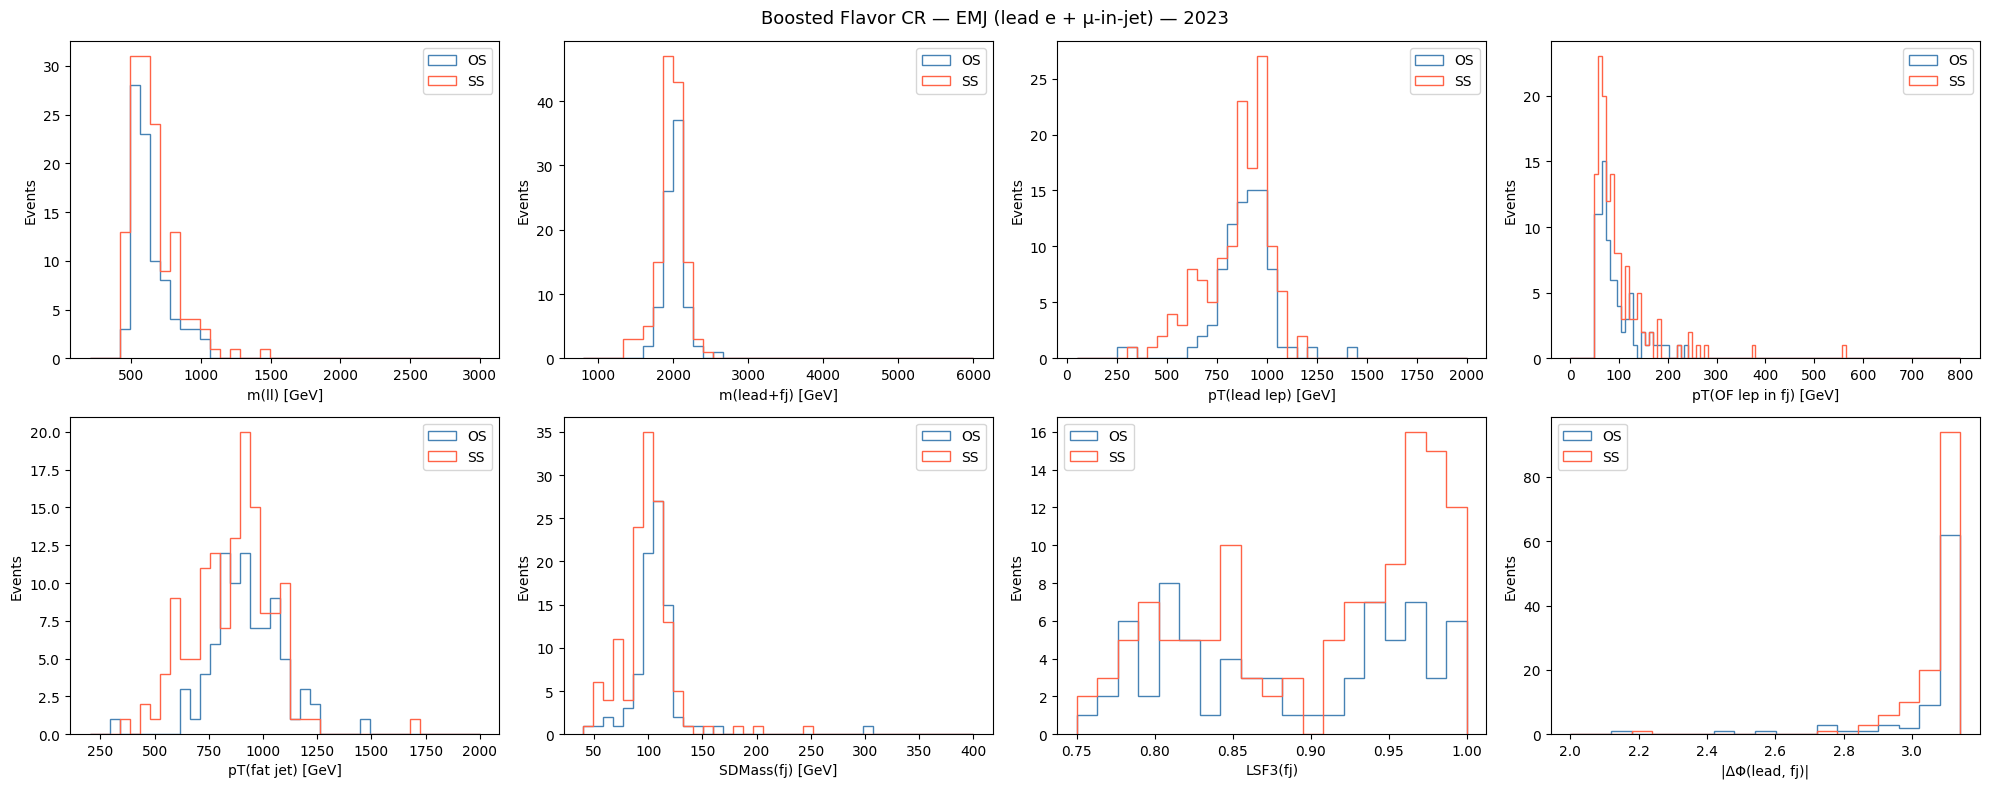

  Saved: boosted_flav_CR_EMJ.png

MEJ (lead μ + e-in-jet): 1 events  (OS=1, SS=0)
  mll  : [936, 936] GeV
  mlljj: [1088, 1088] GeV


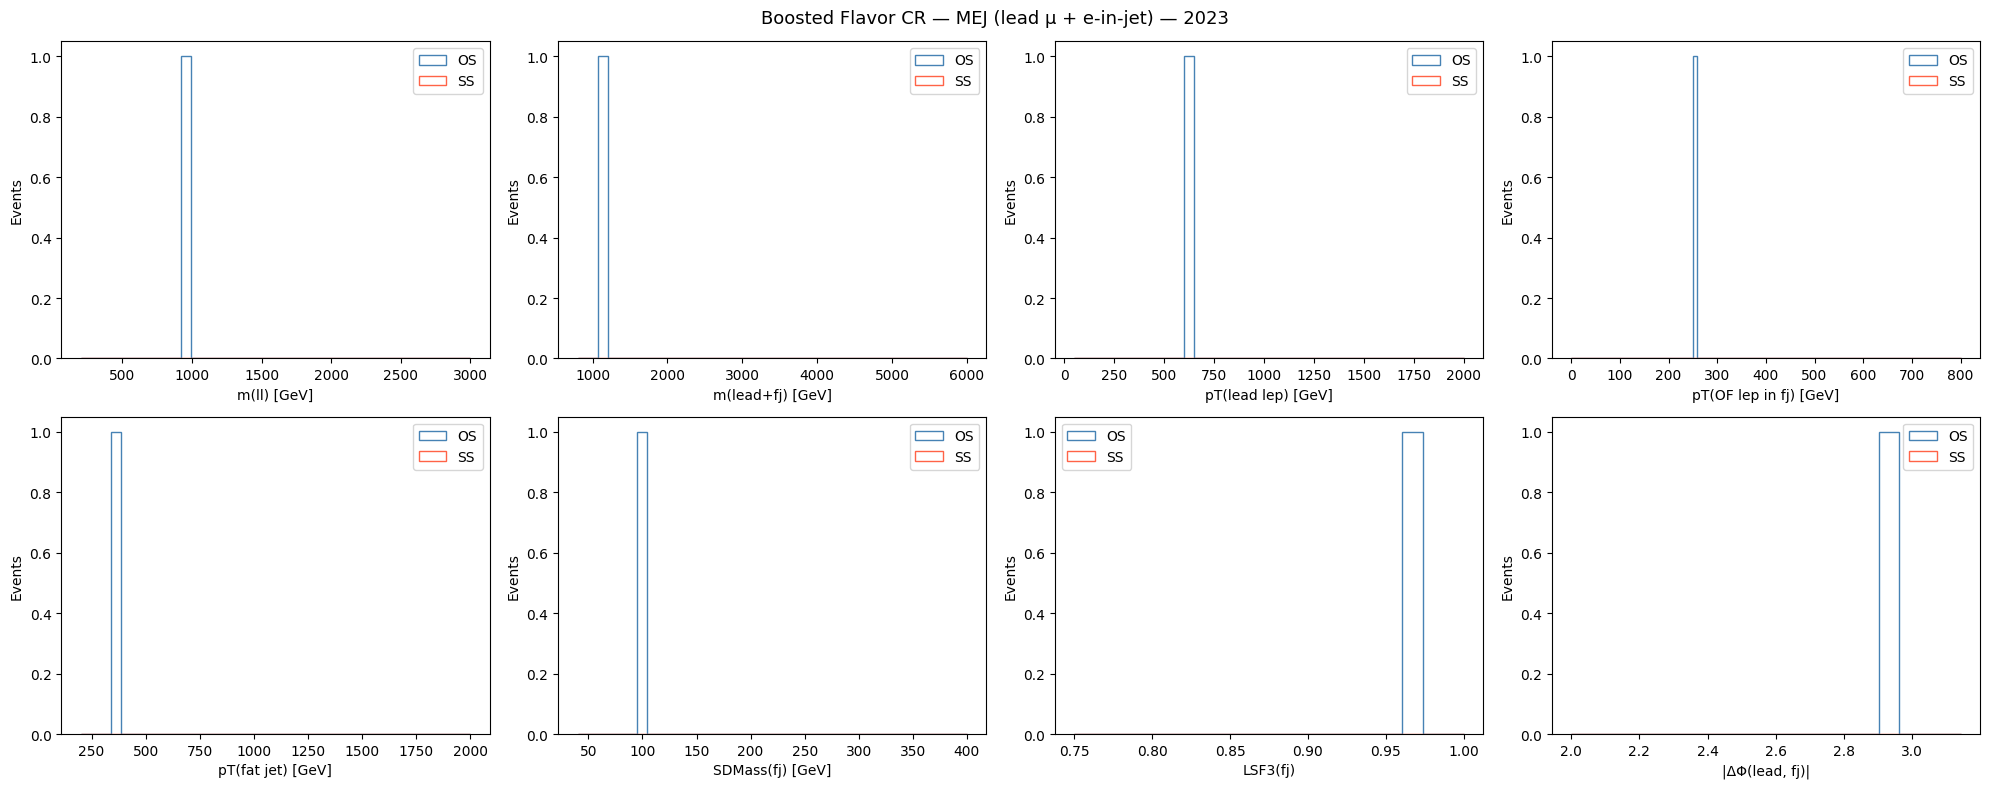

  Saved: boosted_flav_CR_MEJ.png


In [9]:
for label, out in [("EMJ (lead e + μ-in-jet)", out_EMJ), ("MEJ (lead μ + e-in-jet)", out_MEJ)]:
    mll   = out["mll"]
    mlljj = out["mlljj"]
    q     = out["charge_product"]
    n     = len(mll)
    if n == 0:
        print(f"{label}: 0 events"); continue

    OS = q < 0; SS = q > 0
    print(f"\n{label}: {n} events  (OS={OS.sum()}, SS={SS.sum()})")
    print(f"  mll  : [{mll.min():.0f}, {mll.max():.0f}] GeV")
    print(f"  mlljj: [{mlljj.min():.0f}, {mlljj.max():.0f}] GeV")

    fig, axes = plt.subplots(2, 4, figsize=(20, 8))
    fig.suptitle(f"Boosted Flavor CR — {label} — {DATA_ERA}", fontsize=13)

    def h(ax, data, bins, xlabel):
        ax.hist(data[OS], bins=bins, histtype="step", label="OS", color="steelblue")
        ax.hist(data[SS], bins=bins, histtype="step", label="SS", color="tomato")
        ax.set_xlabel(xlabel); ax.set_ylabel("Events"); ax.legend()

    h(axes[0,0], mll,                    np.linspace(200,  3000, 40), "m(ll) [GeV]")
    h(axes[0,1], mlljj,                  np.linspace(800,  6000, 40), "m(lead+fj) [GeV]")
    h(axes[0,2], out["lead_pt"],          np.linspace(50,   2000, 40), "pT(lead lep) [GeV]")
    h(axes[0,3], out["sublep_pt"],        np.linspace(0,    800, 100), "pT(OF lep in fj) [GeV]")
    h(axes[1,0], out["fj_pt"],            np.linspace(200,  2000, 40), "pT(fat jet) [GeV]")
    h(axes[1,1], out["fj_sdm"],           np.linspace(40,    400, 40), "SDMass(fj) [GeV]")
    h(axes[1,2], out["fj_lsf3"],          np.linspace(0.75,   1, 20), "LSF3(fj)")
    h(axes[1,3], out["dphi_lead_fj"],     np.linspace(2.0,  np.pi, 20), "|ΔΦ(lead, fj)|")

    plt.tight_layout()
    tag = label.split()[0]
    plt.savefig(f"boosted_flav_CR_{tag}.png", dpi=150)
    plt.show()
    print(f"  Saved: boosted_flav_CR_{tag}.png")

---
## SF loose lepton inside fat jet — no pT cut

Study how many **same-flavor (SF) loose leptons** fall inside the fat jet when the pT requirement is dropped.

Selection applied up to the `away_fj` stage (lead lepton + trigger + no-low-mll veto + first away LSF fat jet), then:

| Requirement | Value |
|---|---|
| Lepton flavour | Same as lead (e in EMJ, μ in MEJ) |
| Loose ID | `cutBased≥1` or HEEP (e); `looseId` (μ) |
| Inside fat jet | dR(fj, sf_loose) < 0.8 |
| Not the lead lepton | dR(lead, sf_loose) > 0.3 |
| **pT cut** | **None** |

The red dashed line in the pT plot marks the current 53 GeV cut used in the analysis.

In [10]:
# ── SF-in-fatjet study (no pT cut) ────────────────────────────────────────────
SF_DR_FROM_LEAD = 0.3   # exclude lead lepton
SF_DR_IN_FJ     = 0.8   # inside fat jet cone

out_sf = {
    "EMJ": {"sf_pt": [], "n_sf_in_fj": []},
    "MEJ": {"sf_pt": [], "n_sf_in_fj": []},
}

for fpath in tqdm(INPUT_FILES, desc="SF-in-fj study"):
    try:
        f      = uproot.open(fpath)
        events = f["Events"]
    except Exception as e:
        print(f"Cannot open {fpath}: {e}"); continue

    available     = set(events.keys())
    load_branches = [b for b in ALL_BRANCHES if b in available]
    arrays        = events.arrays(load_branches)

    if "FatJet_pt" not in available:
        continue

    # ── Tight leptons ─────────────────────────────────────────────────────────
    el_tight_mask = (
        (arrays["Electron_pt"]  > 10.) & (np.abs(arrays["Electron_eta"]) < 2.5) &
        (arrays["Electron_cutBased"] >= 4)
    )
    mu_tight_mask = (
        (arrays["Muon_pt"]  > 10.) & (np.abs(arrays["Muon_eta"]) < 2.4) &
        (arrays["Muon_highPtId"] == 2) & (arrays["Muon_tkRelIso"] < 0.1)
    )
    el_t_pt   = arrays["Electron_pt"]  [el_tight_mask]
    el_t_eta  = arrays["Electron_eta"] [el_tight_mask]
    el_t_phi  = arrays["Electron_phi"] [el_tight_mask]
    el_t_mass = arrays["Electron_mass"][el_tight_mask]

    mu_t_pt   = arrays["Muon_pt"]  [mu_tight_mask]
    mu_t_eta  = arrays["Muon_eta"] [mu_tight_mask]
    mu_t_phi  = arrays["Muon_phi"] [mu_tight_mask]
    mu_t_mass = arrays["Muon_mass"][mu_tight_mask]

    # ── Loose leptons ─────────────────────────────────────────────────────────
    el_loose_mask = (
        (arrays["Electron_pt"]  > 10.) & (np.abs(arrays["Electron_eta"]) < 2.5) &
        ((arrays["Electron_cutBased"] >= 1) | (arrays["Electron_cutBased_HEEP"] == True))
    )
    mu_loose_mask = (
        (arrays["Muon_pt"]  > 10.) & (np.abs(arrays["Muon_eta"]) < 2.4) &
        (arrays["Muon_looseId"] == True)
    )
    el_l_pt   = arrays["Electron_pt"]  [el_loose_mask]
    el_l_eta  = arrays["Electron_eta"] [el_loose_mask]
    el_l_phi  = arrays["Electron_phi"] [el_loose_mask]
    el_l_mass = arrays["Electron_mass"][el_loose_mask]

    mu_l_pt   = arrays["Muon_pt"]  [mu_loose_mask]
    mu_l_eta  = arrays["Muon_eta"] [mu_loose_mask]
    mu_l_phi  = arrays["Muon_phi"] [mu_loose_mask]
    mu_l_mass = arrays["Muon_mass"][mu_loose_mask]

    # ── LSF fat jets ──────────────────────────────────────────────────────────
    fj_base_mask = (
        (arrays["FatJet_pt"] > FJ_MIN_PT) &
        (np.abs(arrays["FatJet_eta"]) < FJ_MAX_ETA) &
        (arrays["FatJet_msoftdrop"] > FJ_MIN_SDM) &
        (arrays["FatJet_jetId"] >= FJ_TIGHT)
    )
    fj_lsf_mask = fj_base_mask & (arrays["FatJet_lsf3"] > FJ_LSF_CUT)
    fj_pt_ev  = arrays["FatJet_pt"] [fj_lsf_mask]
    fj_eta_ev = arrays["FatJet_eta"][fj_lsf_mask]
    fj_phi_ev = arrays["FatJet_phi"][fj_lsf_mask]

    trig_el = pass_any_trigger(events, EL_TRIGGER_LIST)
    trig_mu = pass_any_trigger(events, MU_TRIGGER_LIST)

    # ── Per-channel collector ──────────────────────────────────────────────────
    def collect_sf_in_fj(
        lead_pt_arr, lead_eta_arr, lead_phi_arr, lead_mass_arr,
        sf_pt_arr,   sf_eta_arr,   sf_phi_arr,   sf_mass_arr,
        trig_safe_pt, trigger_pass, ch,
    ):
        n_lead     = ak.num(lead_pt_arr)
        lead0_pt   = ak.fill_none(ak.firsts(lead_pt_arr),   0.)
        lead0_eta  = ak.fill_none(ak.firsts(lead_eta_arr),  0.)
        lead0_phi  = ak.fill_none(ak.firsts(lead_phi_arr),  0.)
        lead0_mass = ak.fill_none(ak.firsts(lead_mass_arr), 0.)

        # Step 1: exactly 1 tight lead, pT > 60 & trigger safe pT, trigger
        sel = (n_lead == 1) & (lead0_pt > 60.) & (lead0_pt > trig_safe_pt) & trigger_pass
        if ak.sum(sel) == 0:
            return

        lead_pt_m  = lead0_pt  [sel];  lead_eta_m = lead0_eta [sel]
        lead_phi_m = lead0_phi [sel];  lead_mass_m= lead0_mass[sel]
        sf_pt_m  = sf_pt_arr [sel];  sf_eta_m = sf_eta_arr[sel]
        sf_phi_m = sf_phi_arr[sel];  sf_mass_m= sf_mass_arr[sel]
        fj_pt_m  = fj_pt_ev  [sel];  fj_eta_m = fj_eta_ev [sel];  fj_phi_m = fj_phi_ev[sel]

        # Step 2: no low-mll SF lepton veto (same as run_channel)
        dr_lead_sf = delta_r(
            lead_eta_m[:, np.newaxis], lead_phi_m[:, np.newaxis],
            sf_eta_m, sf_phi_m,
        )
        mll_sf = inv_mass_2(
            lead_pt_m[:, np.newaxis],  lead_eta_m[:, np.newaxis],
            lead_phi_m[:, np.newaxis], lead_mass_m[:, np.newaxis],
            sf_pt_m, sf_eta_m, sf_phi_m, sf_mass_m,
        )
        has_lowmll = ak.any((dr_lead_sf > 0.01) & (mll_sf > 60.) & (mll_sf < 150.), axis=1)
        sel2 = ~has_lowmll
        if ak.sum(sel2) == 0:
            return

        lead_eta_m2 = lead_eta_m[sel2];  lead_phi_m2 = lead_phi_m[sel2]
        sf_pt_m2  = sf_pt_m [sel2];  sf_eta_m2 = sf_eta_m[sel2];  sf_phi_m2 = sf_phi_m[sel2]
        fj_pt_m2  = fj_pt_m [sel2];  fj_eta_m2 = fj_eta_m[sel2];  fj_phi_m2 = fj_phi_m[sel2]

        # Step 3: ≥1 LSF fat jet with |ΔΦ(lead, fj)| > 2.0
        dphi_fj = np.abs(delta_phi(lead_phi_m2[:, np.newaxis], fj_phi_m2))
        away_m  = dphi_fj > 2.0
        sel3    = ak.num(fj_pt_m2[away_m]) > 0
        if ak.sum(sel3) == 0:
            return

        lead_eta_m3 = lead_eta_m2[sel3];  lead_phi_m3 = lead_phi_m2[sel3]
        sf_pt_m3  = sf_pt_m2 [sel3];  sf_eta_m3 = sf_eta_m2[sel3];  sf_phi_m3 = sf_phi_m2[sel3]
        fj_eta_m3 = fj_eta_m2[sel3];  fj_phi_m3 = fj_phi_m2[sel3]

        # First away fat jet per event
        dphi3   = np.abs(delta_phi(lead_phi_m3[:, np.newaxis], fj_phi_m3))
        away3   = dphi3 > 2.0
        fj0_eta = ak.fill_none(ak.firsts(fj_eta_m3[away3]), 0.)
        fj0_phi = ak.fill_none(ak.firsts(fj_phi_m3[away3]), 0.)

        # SF loose leptons inside fj: dR(fj,sf)<0.8, dR(lead,sf)>0.3, no pT cut
        dr_fj_sf    = delta_r(fj0_eta[:, np.newaxis], fj0_phi[:, np.newaxis], sf_eta_m3, sf_phi_m3)
        dr_lead_sf3 = delta_r(lead_eta_m3[:, np.newaxis], lead_phi_m3[:, np.newaxis], sf_eta_m3, sf_phi_m3)

        sf_in_fj_mask = (dr_fj_sf < SF_DR_IN_FJ) & (dr_lead_sf3 > SF_DR_FROM_LEAD)

        out_sf[ch]["sf_pt"]     .append(ak.to_numpy(ak.flatten(sf_pt_m3[sf_in_fj_mask])))
        out_sf[ch]["n_sf_in_fj"].append(ak.to_numpy(ak.num(sf_pt_m3[sf_in_fj_mask])))

    collect_sf_in_fj(
        el_t_pt, el_t_eta, el_t_phi, el_t_mass,
        el_l_pt, el_l_eta, el_l_phi, el_l_mass,
        EL_TRIG_SAFE_PT, trig_el, "EMJ",
    )
    collect_sf_in_fj(
        mu_t_pt, mu_t_eta, mu_t_phi, mu_t_mass,
        mu_l_pt, mu_l_eta, mu_l_phi, mu_l_mass,
        MU_TRIG_SAFE_PT, trig_mu, "MEJ",
    )

# Concatenate
for ch in out_sf:
    for k in out_sf[ch]:
        out_sf[ch][k] = np.concatenate(out_sf[ch][k]) if out_sf[ch][k] else np.array([])

print("SF-in-fatjet study complete (no pT cut, dR from lead > 0.3)")
for ch in ["EMJ", "MEJ"]:
    d    = out_sf[ch]
    n_ev = len(d["n_sf_in_fj"])
    if n_ev > 0:
        n_with = int(np.sum(d["n_sf_in_fj"] > 0))
        n_tot  = len(d["sf_pt"])
        frac   = n_with / n_ev * 100
        n_above53 = int(np.sum(d["sf_pt"] > 53.)) if n_tot > 0 else 0
        print(f"  {ch}: {n_ev} events at away_fj stage")
        print(f"    {n_with}/{n_ev} ({frac:.1f}%) have ≥1 SF loose in fj (no pT cut)")
        print(f"    {n_tot} SF leptons total — {n_above53} ({n_above53/n_tot*100:.1f}%) above 53 GeV")
    else:
        print(f"  {ch}: 0 events")

SF-in-fj study: 100%|██████████| 11/11 [00:14<00:00,  1.30s/it]


SF-in-fatjet study complete (no pT cut, dR from lead > 0.3)
  EMJ: 30583 events at away_fj stage
    6413/30583 (21.0%) have ≥1 SF loose in fj (no pT cut)
    6433 SF leptons total — 5933 (92.2%) above 53 GeV
  MEJ: 2 events at away_fj stage
    0/2 (0.0%) have ≥1 SF loose in fj (no pT cut)


ZeroDivisionError: division by zero

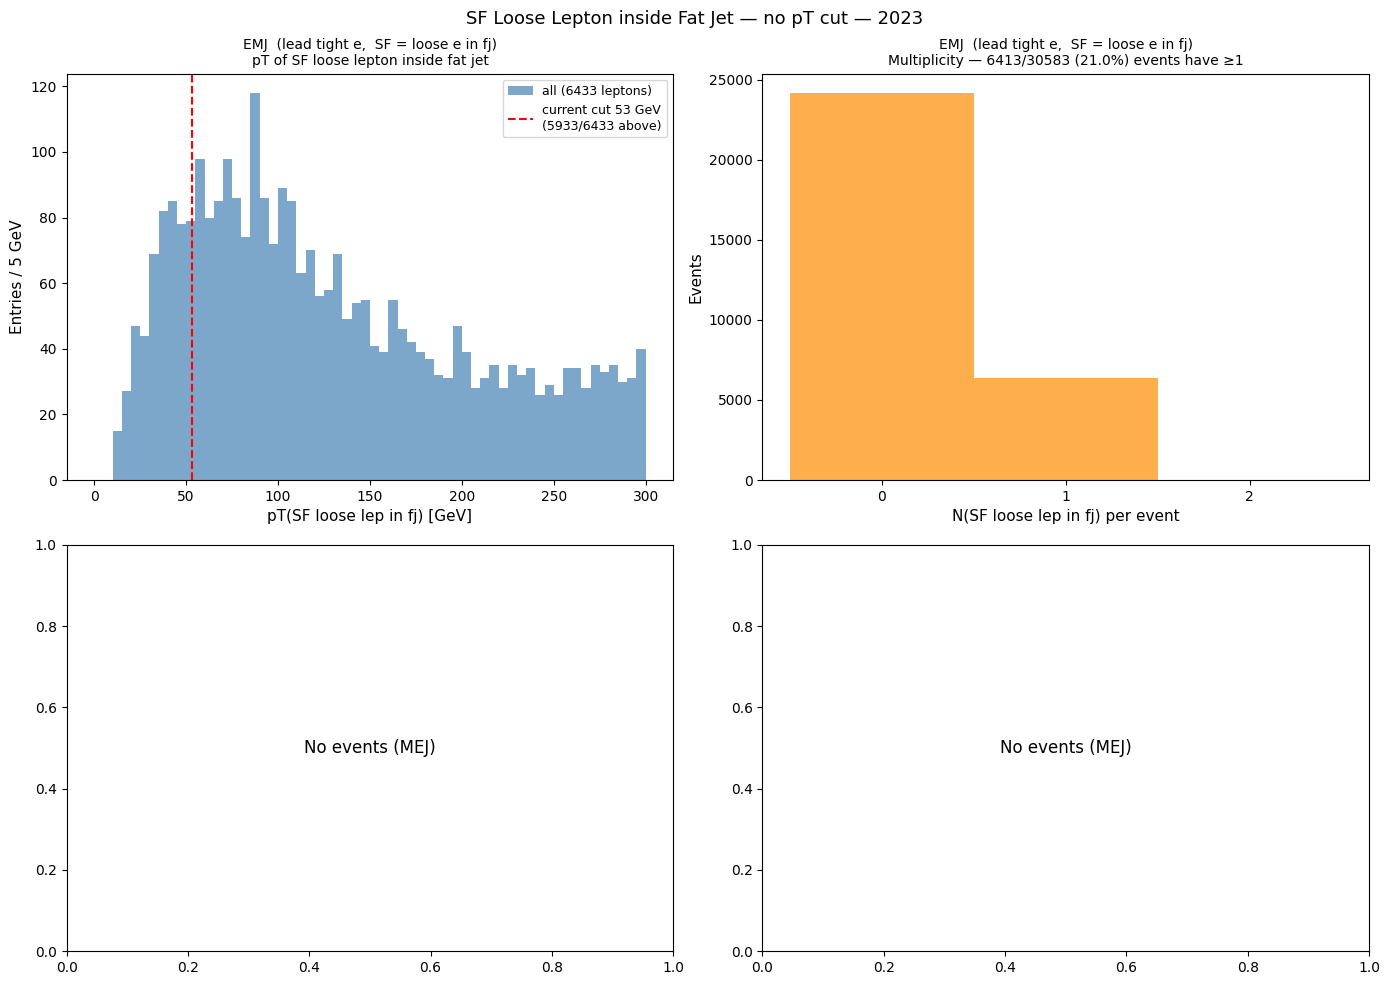

Saved: sf_in_fj_nopt.png


In [11]:
# ── Plot SF lepton pT + multiplicity inside fat jet (no pT cut) ───────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"SF Loose Lepton inside Fat Jet — no pT cut — {DATA_ERA}", fontsize=13)

for i, (ch, label) in enumerate([
    ("EMJ", "EMJ  (lead tight e,  SF = loose e in fj)"),
    ("MEJ", "MEJ  (lead tight μ,  SF = loose μ in fj)"),
]):
    d    = out_sf[ch]
    pt   = d["sf_pt"]
    n_sf = d["n_sf_in_fj"]
    n_ev = len(n_sf)

    ax_pt = axes[i, 0]
    ax_n  = axes[i, 1]

    if n_ev == 0 or len(pt) == 0:
        for ax in (ax_pt, ax_n):
            ax.text(0.5, 0.5, f"No events ({ch})", ha="center", va="center",
                    transform=ax.transAxes, fontsize=12)
        continue

    n_with    = int(np.sum(n_sf > 0))
    n_above53 = int(np.sum(pt > 53.))

    # pT distribution
    bins_pt = np.linspace(0, 300, 61)
    ax_pt.hist(pt, bins=bins_pt, color="steelblue", histtype="stepfilled", alpha=0.7,
               label=f"all ({len(pt)} leptons)")
    ax_pt.axvline(53., color="red", linestyle="--", linewidth=1.5,
                  label=f"current cut 53 GeV\n({n_above53}/{len(pt)} above)")
    ax_pt.set_xlabel("pT(SF loose lep in fj) [GeV]", fontsize=11)
    ax_pt.set_ylabel("Entries / 5 GeV", fontsize=11)
    ax_pt.set_title(f"{label}\npT of SF loose lepton inside fat jet", fontsize=10)
    ax_pt.legend(fontsize=9)

    # Per-event multiplicity
    max_n = int(n_sf.max()) if len(n_sf) > 0 else 1
    bins_n = np.arange(-0.5, max_n + 1.5, 1)
    ax_n.hist(n_sf, bins=bins_n, color="darkorange", histtype="stepfilled", alpha=0.7)
    ax_n.set_xlabel("N(SF loose lep in fj) per event", fontsize=11)
    ax_n.set_ylabel("Events", fontsize=11)
    ax_n.set_title(
        f"{label}\nMultiplicity — {n_with}/{n_ev} ({n_with/n_ev*100:.1f}%) events have ≥1",
        fontsize=10,
    )
    ax_n.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("sf_in_fj_nopt.png", dpi=150)
plt.show()
print("Saved: sf_in_fj_nopt.png")